In [6]:

%load_ext autoreload
%matplotlib widget
%autoreload 2
import matplotlib.pyplot as plt
import numpy as np

from   data_models.test_SS_models import get_models_test_SS
from   data_models.test_SS_data   import get_data_test_SS
from   perlin_noise import PerlinNoise

## Custom styles
##################
plt.rcdefaults()
FS = 9
plt.rc('axes'  ,labelsize=FS)  # xy-labels font
plt.rc('xtick' ,labelsize=FS)  # x-ticks font
plt.rc('ytick' ,labelsize=FS)  # x-ticks font 
plt.rc('legend',fontsize=FS) # legend font
plt.rc('legend',framealpha=1)
plt.rc('lines' ,linewidth=1) # lw



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
def get_noise(t,T, map_values=[-1,2], n_octaves=1):
       
       if n_octaves ==-2:
              v1 = np.random.randint(map_values[0],map_values[1])
              v2 = np.random.randint(map_values[0],map_values[1])
              t2 = t[int(t.size/2)-1]
              return np.where(t<=t2,v1,v2)

       elif n_octaves ==-1: 
            return np.ones_like(t)*map_values[0]*1.0

       elif n_octaves == 0: 
            m = ( map_values[1]-map_values[0] ) / ( t[-1] - t[0] )
            return m*t + map_values[0]

       else:
           seed  = np.random.randint(1_000_000)
           noise = PerlinNoise(octaves=n_octaves, seed=seed)
           a     = map_values[0]
           b     = map_values[1]
           pn    = np.array( [ noise(i/T)  for i in range(t.size) ] )  
           return (b-a)/(np.max(pn) - np.min(pn)) * (pn-np.min(pn)) + a
    

In [8]:
n_hours = 8   # simulation time           (hours)
dt_data = 120 # weather data sampling     (min)
dt_RK45 = 10  # RK45 integration sampling (secs)
t_data  = np.arange(n_hours*60/dt_data+1)*dt_data*60  # (s)

n_octaves = 1
n         = n_octaves
T         = t_data.size

# n_octaves ==-2   # step
# n_octaves ==-1   # cte    map_values[0]
# n_octaves == 0   # linear map_values[0]--map_values[1]
# n_octaves == n   # perlin_noise(n_octaves=n) 
Ws = get_noise(t_data,T/2, map_values=[0.1,3],    n_octaves=-2   ) # wind speed
Wd = get_noise(t_data,T/2, map_values=[1,90],     n_octaves=n   ) # wind angle attack
IT = get_noise(t_data,T/2, map_values=[100,300],  n_octaves=n   ) # solar radiation
Ta = get_noise(t_data,T/2, map_values=[20,30],    n_octaves=n   ) # ambient temperature
I  = get_noise(t_data,T,   map_values=[800,1200], n_octaves=n  ) # current load

# generate the models 
MODE = 1
data = get_data_test_SS(MODE=MODE)
model_cigre, model_ieee = get_models_test_SS(data)


In [9]:
t_data

array([    0.,  7200., 14400., 21600., 28800.])

E3 TRANSIENT TEMPERATURE TRACKING CALCULATION STEPS


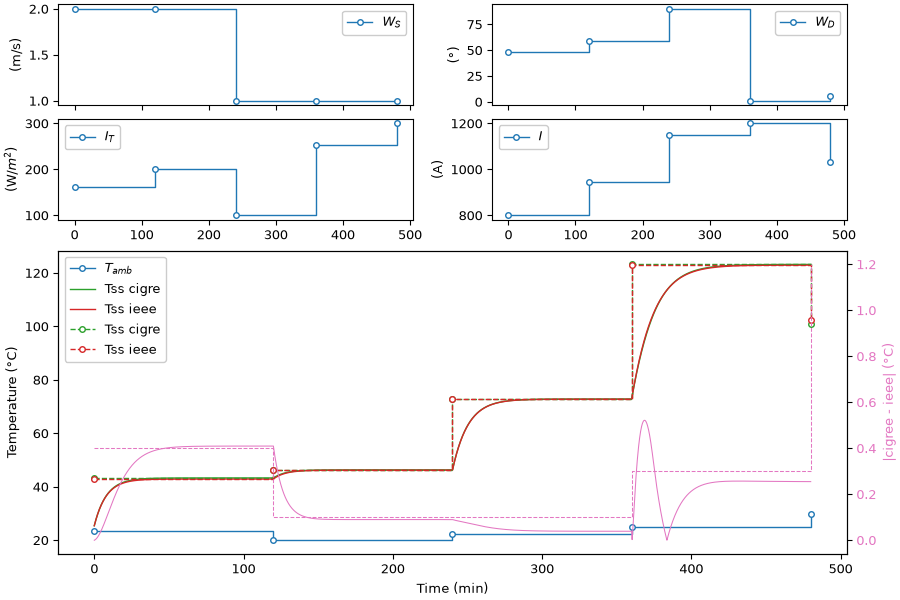

In [10]:
s  = 6
ax = plt.figure(constrained_layout=True, figsize=(1.5*s,s)).subplot_mosaic(
    """
    ab
    cd
    ee
    """,
    gridspec_kw={"height_ratios": [1, 1, 3],"width_ratios":  [1, 1]})

ax1      = ax['e'].twinx()
colorax1 = 'tab:pink'

step_data   = dict(ls='-',  marker='.', mfc='w',  ms=8,where='post')
step_data2  = dict(ls='--', marker='.', mfc='w',  ms=8,where='post')
plot_data_m = dict(ls='-', marker='.', mfc='w',  ms=4)
plot_data_l = dict(ls='-',lw=1)

print('E3 TRANSIENT TEMPERATURE TRACKING CALCULATION STEPS')
keys   = ["$W_S$", "$W_D$", "$I_T$", "$I$", "$T_{amb}$"]
ax_txt = ["a","b","c","d","e"]
y_labels = ["(m/s)","(°)","(W/$m^2$)","(A)","Temperature (°C)"]

def fun_axis(txt):
    ax[txt].set_xticks(t_data/60);
    ax[txt].set_xticklabels( [str(int(i)) if np.mod(i,5)==0 else '' for i in t_data/60] );
    ax[txt].legend();
    ax[txt].grid(linestyle='-.', linewidth=0.25)
    
model_cigre.conditions.mode_solar_radiation_data = True
model_ieee. conditions.mode_solar_radiation_data = True        

T0 = Ta[0]+2
model_cigre.conditions.conductor_temperature = T0 
model_ieee .conditions.conductor_temperature = T0 

t_RK45, Ttr_cigre, data_RK45 = model_cigre.TRAN_Conductor_Temperature(t_data, Ws, Wd, Ta, I, IT, dt_tran=dt_RK45, mode="Step")
t_RK45, Ttr_ieee , data_RK45 = model_ieee. TRAN_Conductor_Temperature(t_data, Ws, Wd, Ta, I, IT, dt_tran=dt_RK45, mode="Step")

Tss_cigre = model_cigre.SS_Conductor_Temperature_arr( Ws, Wd, Ta, I, IT)
Tss_ieee  = model_ieee .SS_Conductor_Temperature_arr( Ws, Wd, Ta, I, IT)


# PLOT WEATHER DATA 
for i, data_i in enumerate([Ws, Wd, IT, I, Ta]): 
    ax[ax_txt[i]].step(t_data/60, data_i,"tab:blue", label=keys[i],**step_data);
    ax[ax_txt[i]].legend(ncols=3)
    ax[ax_txt[i]].set_ylabel(y_labels[i])

# PLOT TRANSIENT TEMPERATURE 
ax["e"].plot(t_RK45/60, Ttr_cigre, label='Tss cigre',  color = "tab:green");
ax["e"].plot(t_RK45/60, Ttr_ieee , label='Tss ieee ' , color = "tab:red"  );

# PLOT STEADY-STATE TEMPERATURE 
ax["e"].step(t_data/60, Tss_cigre,"tab:green", label='Tss cigre',**step_data2);
ax["e"].step(t_data/60, Tss_ieee ,"tab:red",   label='Tss ieee',**step_data2);

error_Ttr = np.abs(Ttr_cigre-Ttr_ieee )
error_Tss = np.abs(Tss_cigre-Tss_ieee )
ax1.plot(t_RK45/60,error_Ttr,colorax1,lw=0.75)
ax1.step(t_data/60,error_Tss,colorax1,lw=0.75,ls='--',where='post')


ax["a"].set_xticklabels([]);
ax["b"].set_xticklabels([]);
ax["e"].set_xlabel('Time (min)')
ax1.set_ylabel('|cigree - ieee| (°C)',color=colorax1)
ax1.tick_params(axis='y', labelcolor=colorax1)
ax['e'].legend()
